In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
lbl_dir = '/datacommons/carlsonlab/srs108/blooms/all_data/'

img_dir = '/datacommons/carlsonlab/srs108/crops/arrowhead_beach/'
transforms = transforms
markers = set()
planet_paths = []
sentinel_paths = {}
cicyano_paths =[]
# img_dir = img_dir
lbl_dir = lbl_dir


for folder in sorted(os.listdir(lbl_dir)):
    if folder not in [".DS_Store", ".ipynb_checkpoints"]:
        folder_path = os.path.join(lbl_dir, folder)
        for file in sorted(os.listdir(folder_path)):
            if file.endswith('.tif'):
                parts = file.split('.')
                name = parts[-3] 
                marker = parts[1][:4] + parts[2]  
                if name == 'truecolor':
#                     cicyano_paths[marker] = os.path.join(folder_path, file)
                    cicyano_paths.append(os.path.join(folder_path,file))
              

# for file in tqdm(cicyano_paths):
#     print(file)


FileNotFoundError: [Errno 2] No such file or directory: '/datacommons/carlsonlab/srs108/blooms/all_data/'

In [3]:
len(cicyano_paths)

3461

In [4]:
latslons = [(36.236724, -76.698134), (36.272006, -76.675842),(36.055163, -76.690760),(36.125495, -76.740141),(36.169908, -76.745905),(36.184133, -76.722858)]

In [5]:
markers = set()
sizes = []
for lat,lon in latslons:
# lat, lon = 36.272006, -76.675842
    sents = []
    for file in tqdm(cicyano_paths):

        with rio.open(file) as rds:
            data = rds.read([1,2,3])
            unalt = data
            crop_size = 3

            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(lon, lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)

            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            sentinel_data = np.array(data)
        #         print(type(np.sum(sentinel_data)))
            if np.sum(sentinel_data) != 0 and np.sum(sentinel_data) != 27432:
        #             print(np.sum(sentinel_data))
        #             plt.imshow(sentinel_data.T)
        #             plt.show()
                sents.append(sentinel_data)
                parts1 = file.split('/')[-1].split('.')[1][:4]
                parts2 = file.split('/')[-1].split('.')[2]
#                 print(parts1, parts2)
                parts = parts1+parts2
#                 break
                if parts not in markers:
                    markers.add(parts)
                    
#                 print(markers)
        sizes.append(len(sents))
    print(len(markers))
    print(len(sents))

  0%|          | 7/3461 [00:00<00:53, 64.37it/s]

1829
2075


  0%|          | 8/3461 [00:00<00:45, 76.44it/s]

1914
2070


  0%|          | 9/3461 [00:00<00:39, 87.59it/s]

...

2070
2100


  0%|          | 8/3461 [00:00<00:51, 66.83it/s]

2091
2097


100%|██████████| 3461/3461 [00:38<00:00, 88.92it/s]

2098
2081


In [23]:
len(markers)

2098

# Get list of planet dates 

In [24]:
planets = []
markersp = set()
root_dir = '/datacommons/carlsonlab/srs108/nc/'
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file == ".DS_Store":
            continue  # Skip system files
        file_path = os.path.join(root, file)
        folder_name = os.path.basename(root)
        if folder_name == "negative":
            class_label = 0
        elif folder_name == "positive":
            class_label = 1
        else:
            continue  # Skip if folder name is not 'positive' or 'negative'

        planets.append(file_path)

        

In [25]:
markersp = set()
for file in (planets):
#     print(file)
    parts = file.split('/')[-1][:8]  
#     print(parts)
    if parts not in markersp:
        markersp.add(parts)

In [26]:

len(markersp)

1077

In [27]:
markerss = markers

# Get list of Sentinel dates

In [96]:
lbl_dir = '/datacommons/carlsonlab/srs108/blooms/all_data'

for folder in sorted(os.listdir(lbl_dir)):
    if folder not in [".DS_Store", ".ipynb_checkpoints"]:
        folder_path = os.path.join(lbl_dir, folder)
        for file in sorted(os.listdir(folder_path)):
            if file.endswith('.tif'):
                parts = file.split('.')
                name = parts[-3] 
                marker = parts[1][:4] + parts[2]  
                if name == 'truecolor':
#                     cicyano_paths[marker] = os.path.join(folder_path, file)
                    cicyano_paths.append(os.path.join(folder_path,file))
              

In [109]:
markers = set()
for file in (cicyano_paths):
#     print(file)
    parts1 = file.split('/')[-1].split('.')[1][:4]
    parts2 = file.split('/')[-1].split('.')[2]
#     print(parts1, parts2)
    parts = parts1 +parts2
#     print(parts)
#     break
    if parts not in markers:
        markers.add(parts)

In [16]:
len((markers))

2098

In [81]:
import pandas as pd

# Define the date range
start_date = '2016-04-01'
end_date = '2024-06-30'
date_range = pd.date_range(start=start_date, end=end_date)

# Create a DataFrame with the date range
df = pd.DataFrame({'Date': date_range})

# Add columns for Planet and Sentinel
df['Planet'] = df['Date'].dt.strftime('%Y%m%d').isin(markersp).astype(int)
df['Sentinel'] = df['Date'].dt.strftime('%Y%m%d').isin(markerss).astype(int)
df['Both'] = ((df['Planet'] == 1) & (df['Sentinel'] == 1)).astype(int)

# Format the Date column to MM-DD-YYYY
df['Date'] = df['Date'].dt.strftime('%m-%d-%Y')

# Display the first few rows
print(df.head())


         Date  Planet  Sentinel  Both
0  04-01-2016       0         0     0
1  04-02-2016       0         0     0
2  04-03-2016       0         0     0
3  04-04-2016       0         0     0
4  04-05-2016       0         0     0


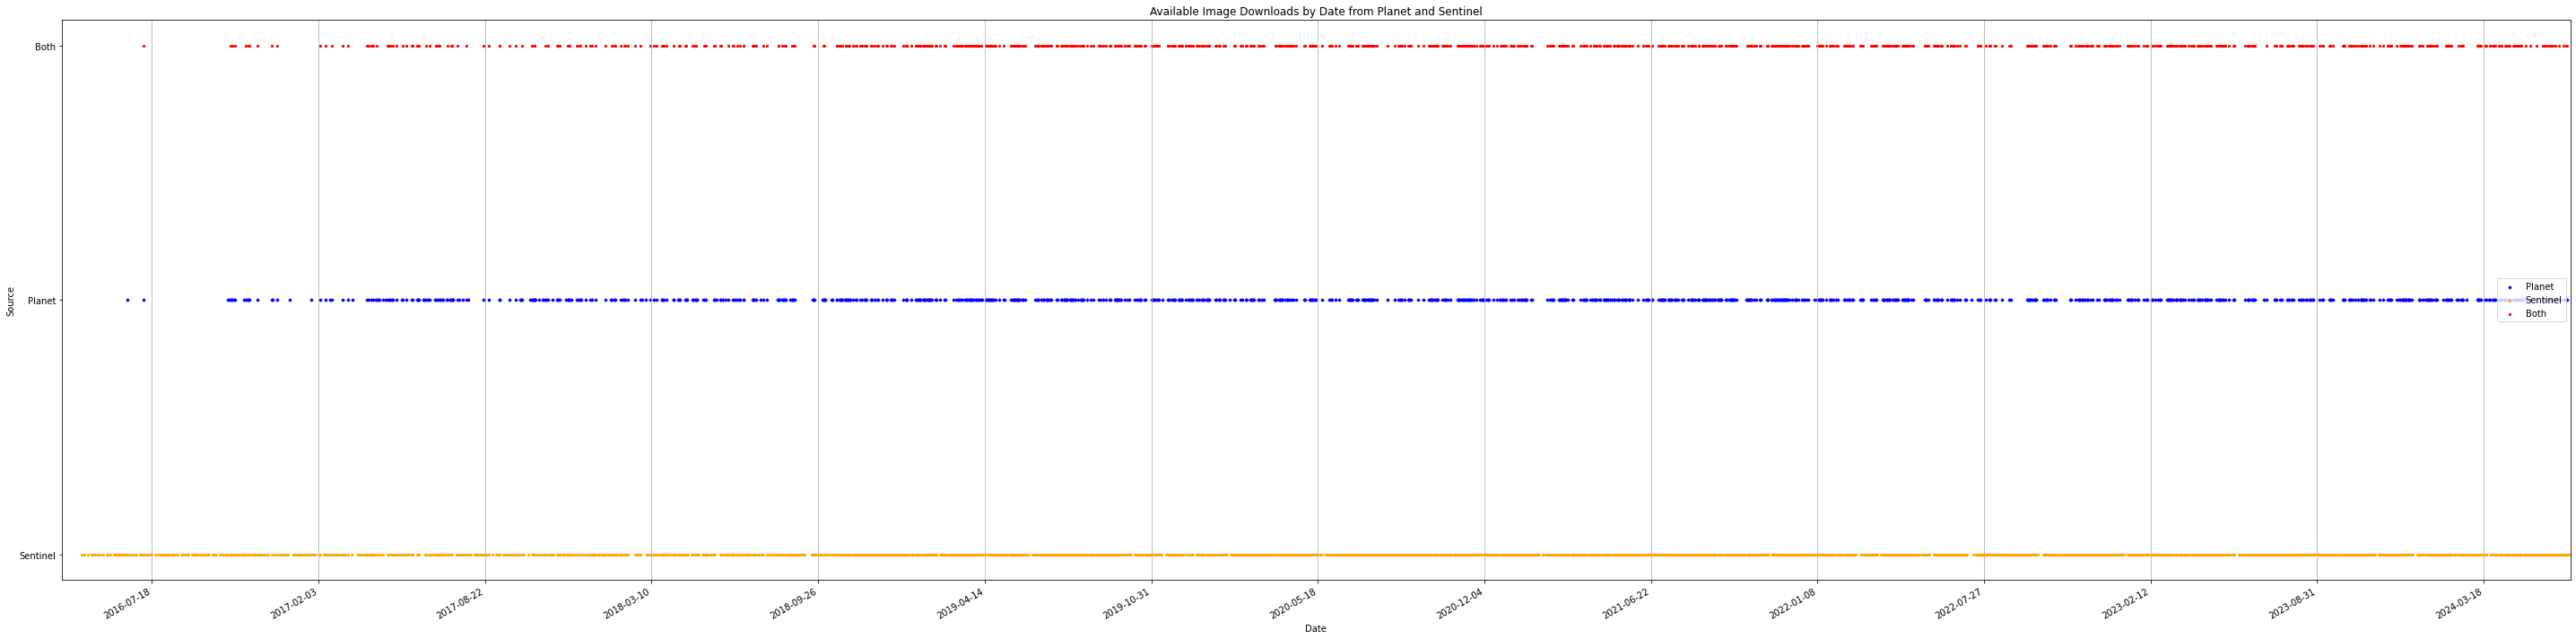

In [94]:
import matplotlib.pyplot as plt

# Convert the Date column back to datetime for plotting
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')

# Create the plot
plt.figure(figsize=(40, 10))

# Adjust y-axis positions for closer spacing
planet_y = 0.53
both_y = 0.56
sentinel_y = 0.5

# Plot the Planet and Sentinel data
plt.scatter(df[df['Planet'] == 1]['Date'], [planet_y] * df[df['Planet'] == 1].shape[0], 
            color='blue', label='Planet', marker='D',s=5)
plt.scatter(df[df['Sentinel'] == 1]['Date'], [sentinel_y] * df[df['Sentinel'] == 1].shape[0], 
            color='orange', label='Sentinel', marker='x',s=5)

plt.scatter(df[df['Both'] == 1]['Date'], [both_y] * df[df['Both'] == 1].shape[0], 
            color='red', label='Both', marker='x',s=5)
# Customize the plot
plt.yticks([sentinel_y, planet_y, both_y], ['Sentinel', 'Planet', 'Both'])
plt.xlabel('Date')
plt.xlim(df['Date'].min(), df['Date'].max())
plt.ylabel('Source')
plt.title('Available Image Downloads by Date from Planet and Sentinel')
plt.legend(loc=5)
plt.grid(True, axis='x')

# Format the x-axis for better readability
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))  # Show only 10 ticks on the x-axis
plt.gcf().autofmt_xdate()  # Rotate x-axis labels

# Show the plot
plt.tight_layout()
plt.show()


In [83]:
df

,Date,Planet,Sentinel,Both
0,2016-04-01,0,0,0
1,2016-04-02,0,0,0
2,2016-04-03,0,0,0
3,2016-04-04,0,0,0
4,2016-04-05,0,0,0
...,...,...,...,...
3008,2024-06-26,1,1,1
3009,2024-06-27,0,0,0
3010,2024-06-28,0,1,0
3011,2024-06-29,0,1,0


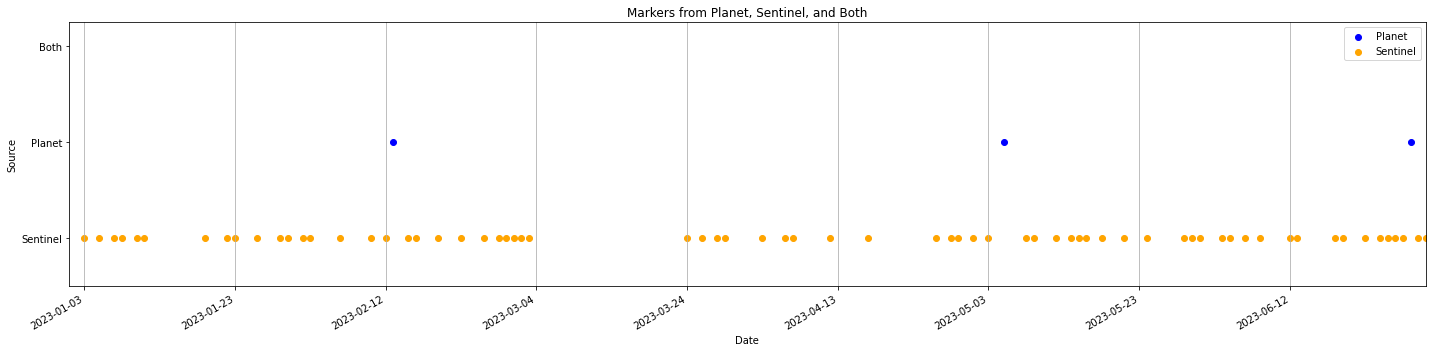

In [89]:
import matplotlib.pyplot as plt

# Convert the Date column back to datetime for plotting
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')

# Adjust y-axis positions for closer spacing
sentinel_y = 0.50
planet_y = 0.54
both_y = 0.58 # Add a y-position for "Both"

# Separate data where 'Both' is 1
both_dates = df[df['Both'] == 1]['Date']

# Separate data where 'Planet' and 'Sentinel' are 1 but 'Both' is 0
planet_only_dates = df[(df['Planet'] == 1) & (df['Both'] == 0) & (df['Sentinel']==0)]['Date']
sentinel_only_dates = df[(df['Sentinel'] == 1) & (df['Both'] == 0)& (df['Planet']==0)]['Date']

# Create the plot
plt.figure(figsize=(20, 5))

# Plot the 'Both' points
# plt.scatter(both_dates, [both_y] * both_dates.shape[0], color='green', label='Both', marker='o')

# Plot the remaining 'Planet' and 'Sentinel' points
plt.scatter(planet_only_dates, [planet_y] * planet_only_dates.shape[0], color='blue', label='Planet', marker='o')
plt.scatter(sentinel_only_dates, [sentinel_y] * sentinel_only_dates.shape[0], color='orange', label='Sentinel', marker='o')

# Customize the plot
plt.yticks([sentinel_y, planet_y, both_y], ['Sentinel', 'Planet', 'Both'])
plt.ylim(0.48, 0.59)  # Adjust the y-axis limits
# plt.xlim(df['Date'].min(), df['Date'].max())  # Set x-axis limits to the min and max dates in the dataset
# Convert the string dates to datetime objects
plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-06-30'))
plt.xlabel('Date')
plt.ylabel('Source')
plt.title('Markers from Planet, Sentinel, and Both')
plt.legend(loc=1)
plt.grid(True, axis='x')

# Format the x-axis for better readability
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  # Show only 10 ticks on the x-axis
plt.gcf().autofmt_xdate()  # Rotate x-axis labels

# Show the plot
plt.tight_layout()
plt.show()
